# Tutorial and Exercise: Attention and Visual Transfomer

In this exercise, we want to look at image classification again, but this time use a visual transformer for the cifar-10 data set that we will set up ourselves using the transformer classes in torch.

We have to install some additional packages (will be changed to be included in the base image :-) ).

We will also first play around with the attention calculation in torch.

In [29]:
!pip install torchinfo torcheval

In [30]:
import cv2
import os
import sys
import numpy as np
import math

import torch
import torch.nn as nn
import torch.optim as optim
from torchinfo import summary
from torcheval.metrics import MulticlassAccuracy
import torchvision


sys.path.append('.')

# for displaying images in jupyter
import matplotlib as mpl
from matplotlib import pyplot as plt

from pathlib import Path

# not the correct directory, but necessary for the last exercise :-)

data_dir = Path('/exchange/cvai/images')

## Attention and transformer mechanisms in torch

### Vectors 
We can construct random vectors like this, in general we will only be interested in the size of the output. Here the vector v simulates a sequence of 10 values with an embedding size of 4.

In [31]:
v = torch.rand([10,4])
print(v)
print(v.shape)

tensor([[0.6681, 0.7401, 0.5804, 0.2464],
        [0.2000, 0.1680, 0.9595, 0.1618],
        [0.7299, 0.5613, 0.2012, 0.8419],
        [0.6388, 0.8116, 0.2403, 0.2003],
        [0.0444, 0.8063, 0.0132, 0.9247],
        [0.9494, 0.3225, 0.9889, 0.4370],
        [0.3957, 0.8025, 0.8637, 0.8738],
        [0.1778, 0.9517, 0.1498, 0.4466],
        [0.6665, 0.6355, 0.6146, 0.5046],
        [0.7289, 0.7646, 0.5902, 0.6066]])
torch.Size([10, 4])


### Calculating attention values

torch has a function `scaled_dot_product_attention` to calculate the attention efficiently.

Lets first look at self-attention, what is the result?

In [32]:
from torch.nn.functional import scaled_dot_product_attention

attention = scaled_dot_product_attention(query=v, value=v, key=v, dropout_p=0.0)
print(attention)
print(attention.shape)

tensor([[0.5473, 0.6584, 0.5418, 0.5286],
        [0.5401, 0.6369, 0.5700, 0.5184],
        [0.5407, 0.6667, 0.5200, 0.5512],
        [0.5404, 0.6676, 0.5221, 0.5313],
        [0.5074, 0.6837, 0.4910, 0.5643],
        [0.5662, 0.6378, 0.5752, 0.5253],
        [0.5366, 0.6618, 0.5449, 0.5498],
        [0.5181, 0.6790, 0.5036, 0.5456],
        [0.5470, 0.6573, 0.5433, 0.5362],
        [0.5470, 0.6613, 0.5391, 0.5406]])
torch.Size([10, 4])


The 10x4 result is actually the attention performed for all the queries.

### Attention with single query
We can also just calculate the result of a single query. So let's use different variables for the query and the key, but keep the values. We need as many keys as we have values. As indicated in the picture below, the result is then a weighted sum of the values

<img src="Attention.png" width="200">

In [33]:
q = torch.rand([1,4])
k = torch.rand([10,4])
v = torch.rand([10,4])

attention = scaled_dot_product_attention(query=q, key=k, value=v)
print(attention)
print(attention.shape)

tensor([[0.6112, 0.3087, 0.5648, 0.6007]])
torch.Size([1, 4])


### Attention with different sizes for query and key

The query and key are used to calculate the attention weight, they do not need to be the same dimensions as the values. This is in fact used in the MultiHeadedAttention where the keys and queries are projected to smaller dimension.

In [34]:
q = torch.rand([1,2])
k = torch.rand([10,2])
v = torch.rand([10,4])

attention = scaled_dot_product_attention(query=q, key=k, value=v)
print(attention)
print(attention.shape)

tensor([[0.5300, 0.6411, 0.4752, 0.4032]])
torch.Size([1, 4])


### Number of parameters

How many trainable variables are there in the attention calculation?

0

## Multiheaded attention

Let us now look at the multiheaded attention class in pytorch that can be used to build the transformer architecture.

We will first look at a single head. If we dont specify the embedding dimensions for the key and value, they will be the same as for the query.

In [35]:
from torch.nn import MultiheadAttention
mha = MultiheadAttention(embed_dim=4, num_heads=1, kdim=None, vdim=None, batch_first=True)

In [36]:
# unbatched example with only one query
q = torch.rand([1,4])
k = torch.rand([10,4])
v = torch.rand([10,4])
with torch.no_grad():
    result, weights = mha.forward(query=q, key=k, value=v)
print(result)
print(result.shape)
print(weights)
print(weights.shape)

tensor([[ 0.2355, -0.2245, -0.1512, -0.0885]])
torch.Size([1, 4])
tensor([[0.1013, 0.0949, 0.0919, 0.1089, 0.0857, 0.1160, 0.0938, 0.1212, 0.0980,
         0.0883]])
torch.Size([1, 10])


## Multiheaded self attention
To calculate the self attention, we just set the query, key and value to the same vector

In [37]:
# unbatched self attention
v = torch.rand([10,4])
with torch.no_grad():
    result, weights = mha.forward(query=v, key=v, value=v)
print(result)
print(result.shape)
print(weights)
print(weights.shape)

tensor([[ 0.2657, -0.2170, -0.1747, -0.0704],
        [ 0.2371, -0.2118, -0.1557, -0.0813],
        [ 0.2486, -0.2131, -0.1634, -0.0762],
        [ 0.2642, -0.2153, -0.1739, -0.0697],
        [ 0.2557, -0.2152, -0.1680, -0.0742],
        [ 0.2541, -0.2142, -0.1671, -0.0743],
        [ 0.2605, -0.2153, -0.1714, -0.0718],
        [ 0.2572, -0.2156, -0.1690, -0.0739],
        [ 0.2514, -0.2153, -0.1651, -0.0767],
        [ 0.2400, -0.2122, -0.1576, -0.0801]])
torch.Size([10, 4])
tensor([[0.1400, 0.0827, 0.0786, 0.0747, 0.1266, 0.0734, 0.0881, 0.1055, 0.1387,
         0.0917],
        [0.1084, 0.0967, 0.0959, 0.0943, 0.1068, 0.0930, 0.0972, 0.1007, 0.1077,
         0.0992],
        [0.1211, 0.0920, 0.0894, 0.0855, 0.1164, 0.0835, 0.0929, 0.1012, 0.1197,
         0.0983],
        [0.1388, 0.0847, 0.0810, 0.0753, 0.1291, 0.0720, 0.0870, 0.1012, 0.1356,
         0.0953],
        [0.1285, 0.0878, 0.0842, 0.0806, 0.1195, 0.0801, 0.0914, 0.1048, 0.1285,
         0.0947],
        [0.1274, 0.0888,

### Multiple heads

What happens to the result if we use multiple heads?

- The query and key values will get projected to lower dimension vectors of size (embedding / nr_heads) for each of the heads with a different project matrix.
- The output of a single head still has the dimension of the value embedding
- So if we concatenate the outputs of all heads the result will have a dimension of embedding * heads.
- The concatenated vector is therefor multiplied by another weight matrix to bring it back to the length of the value embedding.

The result sizes of multiheaded attention is therefor independent of the number of heads.

In [38]:
# same with more heads, each head will project the q and k to a lower dimension, usually d/h
# so the embedding dimension must be devisable by num_heads
v = torch.rand([10,4])
mha = MultiheadAttention(embed_dim=4, num_heads=2, kdim=None, vdim=None, batch_first=True)
with torch.no_grad():
    result, weights = mha.forward(query=v, key=v, value=v)
print(result)
print(result.shape)
print(weights)
print(weights.shape)

tensor([[0.2006, 0.0379, 0.1272, 0.0392],
        [0.1999, 0.0372, 0.1266, 0.0398],
        [0.2010, 0.0379, 0.1273, 0.0395],
        [0.2002, 0.0378, 0.1270, 0.0392],
        [0.1987, 0.0365, 0.1259, 0.0403],
        [0.1996, 0.0376, 0.1264, 0.0387],
        [0.1999, 0.0374, 0.1269, 0.0400],
        [0.1990, 0.0372, 0.1265, 0.0399],
        [0.1983, 0.0369, 0.1257, 0.0392],
        [0.1975, 0.0364, 0.1251, 0.0393]])
torch.Size([10, 4])
tensor([[0.1023, 0.0940, 0.0851, 0.1121, 0.0867, 0.1040, 0.1169, 0.0919, 0.1087,
         0.0984],
        [0.1020, 0.0951, 0.0885, 0.1092, 0.0893, 0.1029, 0.1123, 0.0960, 0.1063,
         0.0984],
        [0.1034, 0.0942, 0.0856, 0.1133, 0.0858, 0.1038, 0.1184, 0.0919, 0.1074,
         0.0961],
        [0.1016, 0.0942, 0.0856, 0.1109, 0.0878, 0.1039, 0.1151, 0.0924, 0.1089,
         0.0998],
        [0.1007, 0.0965, 0.0928, 0.1046, 0.0938, 0.1013, 0.1059, 0.1011, 0.1039,
         0.0996],
        [0.1021, 0.0960, 0.0888, 0.1095, 0.0900, 0.1034, 0.1131,

## Trainable Parameters

How many trainable parameters does the multihead attention have, and what are they for?

In [39]:
class OnlyAttention(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.attention = MultiheadAttention(embed_dim=4, num_heads=1, kdim=4, vdim=4, batch_first=True)
    def forward(self, q, v, k):
        return self.attention.forward(query=q, key=k, value=v)

In [40]:
mha = OnlyAttention()
summary(mha)
print(mha)

for name, param in mha.named_parameters():
    print(name)
    print(param)

OnlyAttention(
  (attention): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=4, out_features=4, bias=True)
  )
)
attention.in_proj_weight
Parameter containing:
tensor([[ 0.2057,  0.3661,  0.1812,  0.5509],
        [ 0.4629,  0.5422,  0.3280, -0.3964],
        [-0.2588, -0.4961,  0.3273,  0.2316],
        [-0.4106,  0.0244,  0.4617,  0.3104],
        [-0.0840, -0.0141, -0.0814, -0.0420],
        [-0.3214,  0.0081,  0.3870,  0.3552],
        [-0.4791,  0.3372, -0.5242,  0.5764],
        [-0.5842, -0.1414,  0.3955, -0.4243],
        [ 0.5109, -0.0441, -0.3577,  0.5249],
        [-0.0849,  0.3293, -0.0960,  0.1732],
        [-0.3362,  0.4040, -0.4955, -0.3436],
        [ 0.5568,  0.0086, -0.5408, -0.0610]], requires_grad=True)
attention.in_proj_bias
Parameter containing:
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], requires_grad=True)
attention.out_proj.weight
Parameter containing:
tensor([[ 0.0641, -0.2970,  0.4021,  0.4464],
        [-0.1163, 

## Transformer Encoder

Finally torch allows to build a transformer or the encoder and decoder seperately. For classification, as needed in the exercises, we only need a encoder.

In [41]:
from torch.nn import TransformerEncoder, TransformerEncoderLayer

layer = TransformerEncoderLayer(d_model=4, nhead=2, dim_feedforward=16, dropout=0.1, batch_first=True)
encoder = TransformerEncoder(layer, num_layers=4)

v = torch.rand([10,4])
result_layer = layer.forward(v)
print(result_layer.shape)

result_encoder = encoder.forward(v)
print(result_encoder.shape)

torch.Size([10, 4])
torch.Size([10, 4])


In [42]:
class TransformEnc(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.layer = TransformerEncoderLayer(d_model=4, nhead=2, dim_feedforward=16, dropout=0.1, batch_first=True)
        self.encoder = TransformerEncoder(self.layer, num_layers=4)

    def forward(self, v):
        return encoder.forward(v)

In [43]:
enc = TransformEnc()
summary(enc)

Layer (type:depth-idx)                                            Param #
TransformEnc                                                      --
├─TransformerEncoderLayer: 1-1                                    --
│    └─MultiheadAttention: 2-1                                    60
│    │    └─NonDynamicallyQuantizableLinear: 3-1                  20
│    └─Linear: 2-2                                                80
│    └─Dropout: 2-3                                               --
│    └─Linear: 2-4                                                68
│    └─LayerNorm: 2-5                                             8
│    └─LayerNorm: 2-6                                             8
│    └─Dropout: 2-7                                               --
│    └─Dropout: 2-8                                               --
├─TransformerEncoder: 1-2                                         --
│    └─ModuleList: 2-9                                            --
│    │    └─TransformerEncoderL

That was all for the tutorial about using attention and transfomers in torch.

## Exercise 1: Image Classification on CIFAR-10 with (own) Vis Transformer

We use the same data and setup as in the last exercise, but this time we would like to train visual transformer.


In [44]:
transform = torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor()])
data_train = torchvision.datasets.CIFAR10(root=data_dir, download=False, transform=transform)
data_test = torchvision.datasets.CIFAR10(root=data_dir, train=False, download=False, transform=transform)

In [45]:
print (f'train: {len(data_train)}')
print (f'train: {len(data_test)}')

train: 50000
train: 10000


In [46]:
BATCH_SIZE = 64

data_train_loader = torch.utils.data.DataLoader(dataset=data_train, shuffle=True, batch_size=BATCH_SIZE)
data_test_loader = torch.utils.data.DataLoader(dataset=data_test, shuffle=False, batch_size=BATCH_SIZE)


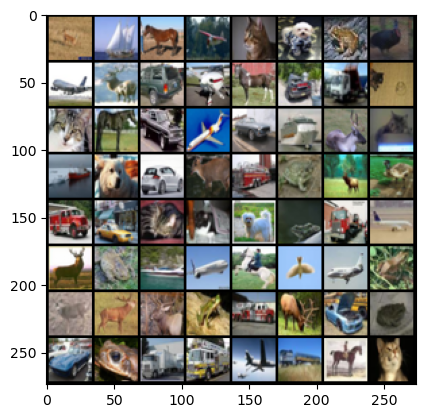

In [47]:
train_iter = iter(data_train_loader)
images, labels = next(train_iter)

plt.imshow(np.transpose(torchvision.utils.make_grid(images), (1, 2, 0)))

As outlined in the presentation, a transfomer needs a positional encoding. This is a standard implementation of the one from the original paper.

In [48]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len):
        super(PositionalEncoding, self).__init__()

        # Create a matrix of shape (max_len, d_model) to store positional encodings
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)

        # Calculate the positional encoding using sine and cosine functions
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        # Register buffer so that it doesn't get updated during training
        self.pe = pe.unsqueeze(0)  # Shape becomes (1, max_len, d_model)
        
    def forward(self, x):
        # x: (batch_size, seq_len, d_model)
        seq_len = x.size(1)
        # Add positional encoding to the input embedding
        x = x + self.pe[:, :seq_len, :].to(x.device)
        return x

## Transformer Implementation

Now implement a transformer using the transformer encoding layers as before. However the first task is to split the input image into blocks. In the original paper, this was 16x16 blocks for the larger imagenet images. The cifar image are smaller (32x32), so we could use 8x8 blocks for example.

Then we use the encoded patches as input to the transformer.



In [49]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=32, patch_size=8, in_channels=3, embed_dim=64):
        super().__init__()
        self.patch_size = patch_size
        self.embed_dim = embed_dim
        self.n_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)  # (batch_size, embed_dim, num_patches, num_patches)
        x = x.flatten(2).transpose(1, 2)  # (batch_size, num_patches, embed_dim)
        return x
    

In [56]:
class VisTrans(nn.Module):
    def __init__(self,
                 embed_dim,
                 hidden_dim,
                 output_dim,
                 n_layers,
                 embedding_dropout,
                 n_heads,
                 dropout
                 ):
        super(VisTrans, self).__init__()
        # YOUR CODE HERE
        self.patch_embedding = PatchEmbedding(32, 8, 3, embed_dim)
        self.positional_encoding = PositionalEncoding(embed_dim, self.patch_embedding.n_patches + 1)

        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, 
                                                   nhead=n_heads, 
                                                   dim_feedforward=hidden_dim, 
                                                   dropout=dropout, 
                                                   activation='gelu',
                                                   batch_first=True)
        
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.embedding_dropout = nn.Dropout(embedding_dropout)
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.fc = nn.Linear(embed_dim, output_dim)

    def forward(self, x):
        # YOUR CODE HERE
        batch_size = x.shape[0]
        x = self.patch_embedding(x)  # (batch_size, num_patches, embed_dim)
        
        # Add class token
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)  # (batch_size, num_patches + 1, embed_dim)
        
        x = self.positional_encoding(x)
        x = self.embedding_dropout(x)
        x = self.transformer_encoder(x)
        
        x = x[:, 0, :]  # Extract class token
        x = self.fc(x)
        return x


In [57]:
model = VisTrans(embed_dim=64, hidden_dim=64, output_dim=10, n_layers=2, embedding_dropout=0.0, n_heads=8, dropout=0.0)
print(model)
summary(model, input_size=(64, 3, 32,32))

VisTrans(
  (patch_embedding): PatchEmbedding(
    (proj): Conv2d(3, 64, kernel_size=(8, 8), stride=(8, 8))
  )
  (positional_encoding): PositionalEncoding()
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=64, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
        (linear2): Linear(in_features=64, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.0, inplace=False)
        (dropout2): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (embedding_dropout): Dropout(p=0.0, inplace=False)
  (fc): Linear(in_features=64, out_features=10, bias=True)
)


Layer (type:depth-idx)                        Output Shape              Param #
VisTrans                                      [64, 10]                  64
├─PatchEmbedding: 1-1                         [64, 16, 64]              --
│    └─Conv2d: 2-1                            [64, 64, 4, 4]            12,352
├─PositionalEncoding: 1-2                     [64, 17, 64]              --
├─Dropout: 1-3                                [64, 17, 64]              --
├─TransformerEncoder: 1-4                     [64, 17, 64]              --
│    └─ModuleList: 2-2                        --                        --
│    │    └─TransformerEncoderLayer: 3-1      [64, 17, 64]              25,216
│    │    └─TransformerEncoderLayer: 3-2      [64, 17, 64]              25,216
├─Linear: 1-5                                 [64, 10]                  650
Total params: 63,498
Trainable params: 63,498
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 13.79
Input size (MB): 0.79
Forward/backward pass si

In [58]:
def get_device():
    if torch.cuda.is_available():
        device = torch.device('cuda')
        # test if it worked
        x = torch.ones(1, device=device)
        print('Using CUDA device')

    elif torch.backends.mps.is_available():
        device = torch.device('mps')
        x = torch.ones(1, device=device)
        print('Using MPS device')
    else:
        print('Using CPU')
        device = torch.device('cpu')
    return device

In [59]:
device = get_device()

Using CUDA device


Training Loop

In [60]:
def train(epochs: int, model, train_data, val_data, loss_function, optimizer, metrics, device):                                              
    input_count = 0
    step_count = 0
    model = model.to(device)
    
    for epoch in range(epochs):
        model.train()
        metrics.reset()
        for step, (inputs, labels) in enumerate(train_data):
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            # Zero your gradients for every batch!
            optimizer.zero_grad()
            # calculate results
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            train_loss = loss_function(outputs, labels)
            train_loss.backward()
            optimizer.step()

            metrics.update(predicted, labels)
            train_acc = metrics.compute()
           
        model.eval()
        metrics.reset()
        val_loss = []
        val_steps = 0
        for step, (inputs, labels) in enumerate(val_data):
            inputs = inputs.to(device)
            labels = labels.to(device)
            with torch.no_grad():
                outputs = model(inputs)
                _, predicted = torch.max(outputs, 1)

                val_loss.append(loss_function(outputs, labels).item())
                metrics.update(predicted, labels)

        val_acc = metrics.compute()
        val_loss_mean = np.mean(val_loss)

        print(f"Epoch {epoch:02} Train Loss: {train_loss:.3f}, Valid Loss: {val_loss_mean:.3f}, Train Accuracy: {train_acc:.2f} Valid Acc: {val_acc:.2f}")
    # return the last accuracy from the evaluation

                       

In [61]:
num_epochs = 5
learning_rate = 0.0001
weight_decay = 0.0

# you can change the parameters to generate the model
model = VisTrans(embed_dim=64, hidden_dim=64, output_dim=10, n_layers=2, embedding_dropout=0.0, n_heads=8, dropout=0.0)
# YOUR CODE HERE
#raise NotImplementedError()

my_metrics = MulticlassAccuracy(num_classes=10)

# initialize an optimizer and loss function and call train

my_optimizer = optim.Adam(model.parameters(), lr=learning_rate)
my_loss = nn.CrossEntropyLoss()
train(num_epochs, model,  data_train_loader, data_test_loader, my_loss, my_optimizer, my_metrics, device)


Epoch 00 Train Loss: 2.215, Valid Loss: 1.877, Train Accuracy: 0.24 Valid Acc: 0.32
Epoch 01 Train Loss: 1.994, Valid Loss: 1.743, Train Accuracy: 0.34 Valid Acc: 0.38
Epoch 02 Train Loss: 1.631, Valid Loss: 1.639, Train Accuracy: 0.39 Valid Acc: 0.42
Epoch 03 Train Loss: 1.036, Valid Loss: 1.581, Train Accuracy: 0.42 Valid Acc: 0.44
Epoch 04 Train Loss: 1.593, Valid Loss: 1.540, Train Accuracy: 0.44 Valid Acc: 0.45


In [62]:
# vision transformers do not work that well on small data sets :-)
# you should still be able to get about 40-50%
assert my_metrics.compute() > 0.4